# **Resgate em Labirinto com Chaves e Portas**

Um robô autônomo de resgate precisa localizar e alcançar um paciente preso em um labirinto. O labirinto contém portas trancadas que bloqueiam a passagem e chaves espalhadas pelo ambiente que abrem essas portas. O robô pode carregar quantas chaves quiser, mas só pode abrir uma porta se já tiver coletado a chave correspondente. O objetivo é encontrar a menor quantidade de movimentos (caminho mínimo) da posição inicial até o paciente, respeitando as restrições de chaves e portas.

#### Regras principais

- O robô se move para cima, baixo, esquerda ou direita (4 direções).

- Não pode atravessar paredes.

- Ao entrar em uma célula com chave, a chave é automaticamente adicionada ao **"inventário"** do robô.

- Ao tentar entrar em uma célula com porta, verifica-se se a chave correspondente está no inventário:
  - **Sim →** pode atravessar  
  - **Não →** movimento bloqueado  

- As chaves não são consumidas ao abrir portas (permanecem no inventário).

- O objetivo é alcançar a célula do paciente (**P**), independentemente das chaves coletadas.


- `collections.deque`: Estrutura de fila eficiente com inserção e remoção rápida nas duas extremidades.

- `time`: Usado para medir tempo de execução, obter horário atual e pausar o programa.

- `tracemalloc`: Monitora o uso de memória do programa.

- `heapq`: Implementa fila de prioridade (heap), acessando rapidamente o menor elemento.

- `typing` (List, Tuple, Set, Dict, Optional): Define tipos para deixar o código mais claro e organizado.

- `math`: Fornece funções matemáticas como raiz, logaritmos e trigonometria.

In [1]:
from collections import deque
import time
import tracemalloc
import heapq
from typing import List, Tuple, Set, Dict, Optional
import math

**Explicação resumida do Módulo 1**

Esse módulo define toda a base do problema de busca no labirinto. A classe `Estado` representa a situação atual do agente, incluindo posição, chaves coletadas, caminho percorrido, profundidade e custo, permitindo comparar e armazenar estados de forma eficiente. Já a classe `Labirinto` representa o ambiente, criando o mapa, identificando início e objetivo e definindo regras como paredes, portas e chaves. Além disso, ela determina quais movimentos são possíveis, aplica ações para gerar novos estados e calcula uma heurística (distância de Manhattan) usada em algoritmos como A*. Em resumo, o módulo organiza o ambiente e a navegação dentro dele, servindo como base para algoritmos de busca.


In [2]:
# ============================================================================
# MODULO 1: DEFINIÇÃO DO ESTADO E LABIRINTO
# ============================================================================

class Estado:
    # Esse método __init__ é o construtor da classe, ou seja, ele é executado
    # automaticamente quando um novo objeto dessa classe é criado. Ele serve
    # para inicializar (definir os valores iniciais) dos atributos do objeto.

    # Nesse caso, ele está representando um "estado" em um problema de busca,
    # como por exemplo a posição de um agente em um labirinto.

    # Parâmetros:
    # - x e y: representam a posição atual (coordenadas) do agente no espaço.
    # - chaves: é um conjunto (Set) que guarda quais chaves o agente já coletou.
    # - caminho: é uma lista que armazena o histórico do caminho percorrido até aqui,
    #   onde cada elemento pode conter informações como posição e ação tomada.
    #   Se nenhum caminho for passado, ele inicia como uma lista vazia.
    # - profundidade: indica quantos passos foram dados desde o estado inicial,
    #   muito usado em algoritmos de busca em profundidade.
    # - custo: representa o custo acumulado até esse estado (g(n)), usado em
    #   algoritmos como o A* para encontrar o caminho de menor custo.

    # Dentro do método:
    # - self.x e self.y armazenam a posição atual.
    # - self.chaves guarda as chaves coletadas.
    # - self.caminho recebe o caminho passado ou, se for None, cria uma lista vazia
    #   para evitar problemas com valores padrão mutáveis.
    # - self.profundidade guarda o nível do estado na árvore de busca.
    # - self.custo guarda o custo acumulado até esse estado.
    def __init__(self, x: int, y: int, chaves: Set[str],
                 caminho: List[Tuple[int, int, str]] = None,
                 profundidade: int = 0,
                 custo: float = 0):
        self.x = x
        self.y = y
        self.chaves = chaves
        self.caminho = caminho if caminho is not None else []
        self.profundidade = profundidade
        self.custo = custo  # custo acumulado g(n) para A*

    # Esse método __eq__ serve para definir como dois objetos dessa classe
    # são comparados usando o operador "==". Ou seja, ele diz quando dois
    # estados devem ser considerados iguais.

    # Parâmetro:
    # - other: é o outro objeto que está sendo comparado com o atual (self).

    # Funcionamento:
    # - Ele compara três coisas:
    #   1. Se as posições x são iguais
    #   2. Se as posições y são iguais
    #   3. Se o conjunto de chaves é igual
    #
    # - Só retorna True (verdadeiro) se TODOS esses elementos forem iguais.
    # - Caso qualquer um seja diferente, retorna False (falso).

    # Isso é muito importante em problemas de busca, porque permite identificar
    # se dois estados são iguais, evitando explorar estados repetidos.
    def __eq__(self, other):
        return (self.x == other.x and
                self.y == other.y and
                self.chaves == other.chaves)

    # Esse método __hash__ define um valor numérico (hash) para o objeto,
    # permitindo que ele seja usado em estruturas como conjuntos (set)
    # e dicionários (dict).

    # Em problemas de busca, isso é muito importante para guardar estados
    # já visitados de forma eficiente, evitando repetições.

    # Funcionamento:
    # - Ele cria uma "assinatura" única do estado com base em:
    #   1. A posição x
    #   2. A posição y
    #   3. As chaves coletadas
    #
    # - Esses valores são agrupados em uma tupla:
    #   (self.x, self.y, frozenset(self.chaves))

    # Por que usar frozenset?
    # - Porque o tipo set (conjunto normal) não pode ser usado em hash,
    #   já que é mutável (pode mudar).
    # - O frozenset é uma versão imutável do set, então pode ser usado
    #   dentro do hash sem problemas.

    # - A função hash(...) do Python então transforma essa tupla em um número,
    #   que representa o estado de forma única.

    # Importante:
    # - Esse método deve ser consistente com o __eq__.
    # - Ou seja, se dois objetos são iguais (==), eles devem ter o mesmo hash.
    def __hash__(self):
        return hash((self.x, self.y, frozenset(self.chaves)))

    # Esse método __str__ define como o objeto será representado em forma de texto
    # quando você usar funções como print() ou str().

    # Ou seja, ele serve para facilitar a visualização do estado de forma legível,
    # principalmente para debug (ver o que está acontecendo no código).

    # Funcionamento:
    # - Ele retorna uma string formatada (f-string) contendo:
    #   1. A posição (x, y)
    #   2. As chaves coletadas
    #   3. A profundidade do estado na busca

    # Exemplo de saída:
    # (2,3, chaves={'A', 'B'}, prof=4)

    # Isso ajuda a entender rapidamente em que ponto da busca o estado está.
    def __str__(self):
        return f"({self.x},{self.y}, chaves={self.chaves}, prof={self.profundidade})"


class Labirinto:
    """Classe para gerenciar o labirinto e suas operações"""

    # Esse método __init__ é o construtor da classe, responsável por inicializar
    # um objeto que representa um labirinto. Ele define todas as informações
    # necessárias para começar a trabalhar com esse ambiente.

    # Parâmetros:
    # - labirinto: é uma matriz (lista de listas) que representa o mapa do labirinto.
    #   Cada posição pode conter símbolos como paredes, caminho, início, objetivo, etc.
    #   Se nenhum labirinto for passado, ele cria automaticamente um padrão.
    # - nome: é apenas uma identificação do labirinto (uma string).

    # Funcionamento geral:
    # - Ele configura o labirinto, identifica suas dimensões, encontra pontos
    #   importantes (início e objetivo) e define os movimentos possíveis.

    def __init__(self, labirinto: List[List[str]] = None, nome: str = "Labirinto"):

        # Define o labirinto:
        # - Se um labirinto foi passado, usa ele.
        # - Caso contrário, chama um método interno que cria um labirinto padrão.
        self.labirinto = labirinto if labirinto else self._criar_labirinto_padrao()

        # Guarda o nome do labirinto
        self.nome = nome

        # Calcula o número de linhas do labirinto
        self.linhas = len(self.labirinto)

        # Calcula o número de colunas (assume que todas as linhas têm o mesmo tamanho)
        self.colunas = len(self.labirinto[0])

        # Encontra a posição inicial (marcada com 'R' no labirinto)
        self.inicio = self._encontrar_posicao('R')

        # Encontra a posição objetivo (marcada com 'P')
        self.objetivo = self._encontrar_posicao('P')

        # Define os movimentos possíveis dentro do labirinto
        # Cada direção está associada a uma mudança na posição (linha, coluna):
        # - CIMA: diminui a linha
        # - BAIXO: aumenta a linha
        # - ESQUERDA: diminui a coluna
        # - DIREITA: aumenta a coluna
        self.direcoes = {
            'CIMA': (-1, 0),
            'BAIXO': (1, 0),
            'ESQUERDA': (0, -1),
            'DIREITA': (0, 1)
        }

    # Esse método _criar_labirinto_padrao é responsável por gerar um labirinto
    # padrão para testes, caso nenhum labirinto seja fornecido ao criar o objeto.

    # Observação:
    # - O "_" no início do nome indica que esse método é "interno" da classe,
    #   ou seja, ele é feito para ser usado dentro da própria classe e não
    #   diretamente por quem está usando o código.

    # Funcionamento:
    # - Ele retorna uma matriz (lista de listas), onde cada elemento representa
    #   uma posição no labirinto.

    # Significado dos símbolos:
    # - 'R' → posição inicial (onde o agente começa)
    # - 'P' → objetivo (onde o agente deve chegar)
    # - '.' → caminho livre (pode andar)
    # - '#' → parede (não pode passar)
    # - 'K_A' → chave A (deve ser coletada)
    # - 'D_A' → porta A (só pode passar se tiver a chave correspondente)

    # Esse labirinto é pequeno e simples, ideal para testar algoritmos de busca.
    def _criar_labirinto_padrao(self):
        """Cria labirinto padrão para testes"""
        return [
            ['R', '.', '.', '.', '#', '.'],
            ['.', '#', 'K_A', '.', '#', '.'],
            ['.', '#', '.', 'D_A', '.', '.'],
            ['.', '.', '.', '.', '.', '.'],
            ['.', '#', '.', '#', '.', '.'],
            ['.', '.', '.', '.', 'P', '.']
        ]

    # Esse método _encontrar_posicao é responsável por localizar onde um
    # determinado caractere está dentro do labirinto.

    # Parâmetro:
    # - caractere: é o símbolo que queremos encontrar no labirinto
    #   (por exemplo: 'R' para início ou 'P' para objetivo).

    # Retorno:
    # - Se encontrar, retorna uma tupla (i, j), que representa:
    #   i → linha
    #   j → coluna
    # - Se não encontrar, retorna None.

    # Funcionamento:
    # - Ele percorre todo o labirinto usando dois loops:
    #   1. O primeiro (i) percorre as linhas
    #   2. O segundo (j) percorre as colunas
    #
    # - Em cada posição, ele verifica se o valor é igual ao caractere buscado.
    # - Assim que encontra, já retorna a posição imediatamente.

    # Observação:
    # - O "_" no nome indica que esse método é interno da classe.
    def _encontrar_posicao(self, caractere: str) -> Tuple[int, int]:
        """Encontra a posição de um caractere no labirinto"""

        # Percorre todas as linhas
        for i in range(self.linhas):

            # Percorre todas as colunas
            for j in range(self.colunas):

                # Verifica se o elemento atual é o caractere procurado
                if self.labirinto[i][j] == caractere:

                    # Retorna a posição (linha, coluna)
                    return (i, j)

        # Caso não encontre o caractere, retorna None
        return None

    # Esse método _eh_chave serve para verificar se uma determinada célula
    # do labirinto contém uma chave.

    # Parâmetro:
    # - celula: é o valor que está em uma posição do labirinto (pode ser '.', '#', 'K_A', etc).

    # Retorno:
    # - Retorna True (verdadeiro) se a célula for uma chave.
    # - Retorna False (falso) caso contrário.

    # Funcionamento:
    # - Primeiro, ele verifica se o valor da célula é uma string usando isinstance.
    #   Isso evita erros caso o valor não seja texto.
    #
    # - Depois, ele verifica se essa string começa com 'K_'.
    #   Esse padrão é usado para identificar chaves (ex: 'K_A', 'K_B').

    # - Se ambas as condições forem verdadeiras, então é uma chave.

    # Observação:
    # - O "_" no início indica que esse método é interno da classe.
    def _eh_chave(self, celula) -> bool:
        """Verifica se a célula contém uma chave"""

        # Verifica se é uma string E se começa com 'K_'
        return isinstance(celula, str) and celula.startswith('K_')

    # Esse método _tipo_chave serve para identificar qual é o "tipo" da chave
    # presente em uma célula do labirinto (por exemplo: 'A', 'B', etc).

    # Parâmetro:
    # - celula: é o valor da posição no labirinto (ex: 'K_A', '.', '#').

    # Retorno:
    # - Retorna uma string com o tipo da chave (ex: 'A') se for uma chave.
    # - Retorna None se a célula não for uma chave.

    # Funcionamento:
    # - Primeiro, ele usa o método _eh_chave para verificar se a célula realmente
    #   contém uma chave.
    #
    # - Se for uma chave (ex: 'K_A'):
    #   - Ele acessa o índice 2 da string (celula[2]), que corresponde à letra
    #     que identifica o tipo da chave.
    #     Exemplo: 'K_A' → índice 0='K', 1='_', 2='A'
    #
    # - Se não for uma chave, retorna None.

    # Observação:
    # - O "_" indica que esse método é interno da classe.
    def _tipo_chave(self, celula) -> Optional[str]:
        """Retorna o tipo da chave"""
        # Verifica se a célula contém uma chave
        if self._eh_chave(celula):
            # Retorna o tipo da chave (ex: 'A' em 'K_A')
            return celula[2]
        # Caso não seja uma chave, retorna None
        return None

    # Esse método _eh_porta serve para verificar se uma determinada célula
    # do labirinto contém uma porta.

    # Parâmetro:
    # - celula: é o valor presente em uma posição do labirinto
    #   (ex: '.', '#', 'D_A', 'K_A', etc).

    # Retorno:
    # - Retorna True (verdadeiro) se a célula for uma porta.
    # - Retorna False (falso) caso contrário.

    # Funcionamento:
    # - Primeiro, ele verifica se o valor da célula é uma string,
    #   usando isinstance, para evitar erros com outros tipos.
    #
    # - Depois, verifica se essa string começa com 'D_'.
    #   Esse padrão é usado para identificar portas (ex: 'D_A', 'D_B').

    # - Se as duas condições forem verdadeiras, então a célula é uma porta.

    # Observação:
    # - O "_" no início indica que esse método é interno da classe.
    def _eh_porta(self, celula) -> bool:
        """Verifica se a célula contém uma porta"""
        return isinstance(celula, str) and celula.startswith('D_')

    # Esse método _tipo_porta serve para identificar qual é o "tipo" da porta
    # presente em uma célula do labirinto (por exemplo: 'A', 'B', etc).

    # Parâmetro:
    # - celula: é o valor da posição no labirinto (ex: 'D_A', '.', '#').

    # Retorno:
    # - Retorna uma string com o tipo da porta (ex: 'A') se for uma porta.
    # - Retorna None se a célula não for uma porta.

    # Funcionamento:
    # - Primeiro, ele usa o método _eh_porta para verificar se a célula realmente
    #   contém uma porta.
    #
    # - Se for uma porta (ex: 'D_A'):
    #   - Ele acessa o índice 2 da string (celula[2]), que corresponde à letra
    #     que identifica o tipo da porta.
    #     Exemplo: 'D_A' → índice 0='D', 1='_', 2='A'
    #
    # - Se não for uma porta, retorna None.

    # Observação:
    # - O "_" indica que esse método é interno da classe.
    def _tipo_porta(self, celula) -> Optional[str]:
        """Retorna o tipo da porta"""

        # Verifica se a célula contém uma porta
        if self._eh_porta(celula):

            # Retorna o tipo da porta (ex: 'A' em 'D_A')
            return celula[2]

        # Caso não seja uma porta, retorna None
        return None

    # Esse método estado_inicial é responsável por criar e retornar
    # o estado inicial do problema de busca no labirinto.

    # Retorno:
    # - Retorna um objeto do tipo Estado, que representa o ponto de partida
    #   do agente dentro do labirinto.

    # Funcionamento:
    # - Ele utiliza a posição inicial armazenada em self.inicio,
    #   que foi encontrada anteriormente (onde está o 'R' no labirinto).
    #
    # - self.inicio é uma tupla no formato (linha, coluna), então:
    #   - self.inicio[0] → linha (x)
    #   - self.inicio[1] → coluna (y)
    #
    # - Também cria um conjunto vazio set(), indicando que o agente
    #   começa sem nenhuma chave.

    # - Esse estado inicial é a base para os algoritmos de busca,
    #   que irão explorar o labirinto a partir desse ponto.
    def estado_inicial(self) -> Estado:
        """Retorna o estado inicial"""

        # Cria e retorna o estado inicial:
        # - posição inicial (x, y)
        # - conjunto vazio de chaves
        return Estado(self.inicio[0], self.inicio[1], set())

    # Esse método teste_objetivo serve para verificar se um determinado estado
    # representa o objetivo do problema (ou seja, se o agente chegou ao destino).

    # Parâmetro:
    # - estado: é um objeto do tipo Estado, que contém a posição atual do agente
    #   no labirinto.

    # Retorno:
    # - Retorna True (verdadeiro) se o estado atual for o objetivo.
    # - Retorna False (falso) caso contrário.

    # Funcionamento:
    # - Ele compara a posição atual do agente (estado.x, estado.y)
    #   com a posição do objetivo (self.objetivo).
    #
    # - self.objetivo é uma tupla (linha, coluna), então:
    #   - self.objetivo[0] → linha do objetivo
    #   - self.objetivo[1] → coluna do objetivo
    #
    # - Só retorna True se BOTH (linha e coluna) forem iguais.

    # Observação:
    # - Esse método é essencial em algoritmos de busca, pois define
    #   quando a solução foi encontrada.
    def teste_objetivo(self, estado: Estado) -> bool:
        """Verifica se o estado é o objetivo"""
        # Compara a posição atual com a posição do objetivo
        return (estado.x == self.objetivo[0] and
                estado.y == self.objetivo[1])

    # Esse método acoes_aplicaveis é responsável por determinar quais ações
    # (movimentos) o agente pode realizar a partir do estado atual.

    # Parâmetro:
    # - estado: objeto do tipo Estado, que contém a posição atual do agente
    #   e as chaves que ele já possui.

    # Retorno:
    # - Retorna uma lista de ações válidas.
    # - Cada ação é representada como uma tupla:
    #   (nome_da_acao, (dx, dy))
    #   Exemplo: ('CIMA', (-1, 0))

    # Funcionamento geral:
    # - Para cada direção possível (CIMA, BAIXO, etc), o método verifica
    #   se o movimento é válido dentro do labirinto.
    def acoes_aplicaveis(self, estado: Estado) -> List[Tuple[str, Tuple[int, int]]]:
        """Retorna lista de ações aplicáveis no estado atual"""

        # Lista que armazenará as ações válidas
        acoes_validas = []

        # Percorre todas as direções possíveis
        for nome_acao, (dx, dy) in self.direcoes.items():

            # Calcula a nova posição após aplicar o movimento
            x_novo = estado.x + dx
            y_novo = estado.y + dy

            # Verifica se a nova posição está dentro dos limites do labirinto
            if not (0 <= x_novo < self.linhas and 0 <= y_novo < self.colunas):
                continue  # ignora essa ação

            # Obtém o conteúdo da célula de destino
            celula = self.labirinto[x_novo][y_novo]

            # Se for uma parede, não pode passar
            if celula == '#':
                continue

            # Se for uma porta, verifica se o agente tem a chave correspondente
            if self._eh_porta(celula):
                tipo_porta = self._tipo_porta(celula)

                # Se não tiver a chave, não pode passar
                if tipo_porta not in estado.chaves:
                    continue

            # Se passou por todas as verificações, a ação é válida
            acoes_validas.append((nome_acao, (dx, dy)))

        # Retorna a lista de ações válidas
        return acoes_validas


    # Esse método transicao é responsável por aplicar uma ação em um estado atual
    # e gerar um novo estado com base nesse movimento.

    # Parâmetros:
    # - estado: representa o estado atual do agente (posição, chaves, caminho, etc).
    # - acao: uma tupla no formato (nome_da_acao, (dx, dy)),
    #   onde (dx, dy) indica o deslocamento no labirinto.

    # Retorno:
    # - Retorna um novo objeto Estado com as informações atualizadas após a ação.

    # Funcionamento:
    # - Ele calcula a nova posição do agente.
    # - Verifica se o movimento é válido (dentro dos limites).
    # - Atualiza as chaves, caso encontre alguma.
    # - Atualiza o caminho percorrido.
    # - Atualiza o custo e a profundidade.
    def transicao(self, estado: Estado, acao: Tuple[str, Tuple[int, int]]) -> Estado:
        """Aplica uma ação e retorna o novo estado"""

        # Extrai o deslocamento da ação (dx, dy)
        dx, dy = acao[1]

        # Calcula a nova posição após o movimento
        x_novo = estado.x + dx
        y_novo = estado.y + dy

        # Verifica se a nova posição está dentro dos limites do labirinto
        if not (0 <= x_novo < self.linhas and 0 <= y_novo < self.colunas):
            return estado  # se sair do limite, mantém o estado atual

        # Cria uma cópia das chaves atuais (evita alterar o estado original)
        novas_chaves = set(estado.chaves)

        # Obtém o conteúdo da célula de destino
        celula = self.labirinto[x_novo][y_novo]

        # Se a célula contém uma chave, coleta ela
        if self._eh_chave(celula):
            tipo_chave = self._tipo_chave(celula)
            novas_chaves.add(tipo_chave)

        # Atualiza o caminho adicionando a nova posição e a ação tomada
        novo_caminho = estado.caminho + [(x_novo, y_novo, acao[0])]

        # Atualiza o custo acumulado (cada movimento custa 1)
        novo_custo = estado.custo + 1  # custo de movimento

        # Retorna um novo estado com todas as informações atualizadas
        return Estado(
            x_novo,
            y_novo,
            novas_chaves,
            novo_caminho,
            estado.profundidade + 1,  # incrementa a profundidade
            novo_custo
        )

    # Esse método heuristica_manhattan calcula uma estimativa de distância
    # entre o estado atual e o objetivo, utilizando a distância de Manhattan.
    # Essa heurística é muito usada no algoritmo A* para guiar a busca.

    # Parâmetro:
    # - estado: objeto do tipo Estado, que contém a posição atual do agente.

    # Retorno:
    # - Retorna um valor numérico (float) que representa a distância estimada
    #   até o objetivo.

    # Funcionamento:
    # - A distância de Manhattan considera apenas movimentos em linha reta
    #   (cima, baixo, esquerda, direita), ou seja, sem diagonais.
    #
    # - A fórmula basicamente soma:
    #   |diferença nas linhas| + |diferença nas colunas|

    # - estado.x e estado.y → posição atual
    # - self.objetivo[0] e self.objetivo[1] → posição do objetivo

    # - A função abs(...) garante que a diferença seja sempre positiva.

    # Observação:
    # - Essa heurística é admissível em muitos problemas de grade,
    #   pois nunca superestima o custo real até o objetivo.
    def heuristica_manhattan(self, estado: Estado) -> float:
        """Heurística de Manhattan para A*"""
        return abs(estado.x - self.objetivo[0]) + abs(estado.y - self.objetivo[1])

    # Esse método imprimir é responsável por mostrar o labirinto no console
    # de forma organizada e legível para o usuário.

    # Funcionamento geral:
    # - Ele imprime um título com o nome do labirinto.
    # - Depois percorre cada linha do labirinto e monta uma string para exibição.
    # - Por fim, imprime uma legenda explicando os símbolos utilizados.
    def imprimir(self):
        """Imprime o labirinto"""

        # Imprime uma linha decorativa
        print(f"\n{'='*60}")

        # Mostra o nome do labirinto
        print(f"LABIRINTO: {self.nome}")

        # Imprime outra linha decorativa
        print(f"{'='*60}")

        # Percorre cada linha do labirinto
        for linha in self.labirinto:

            # String que vai representar a linha
            linha_str = ''

            # Percorre cada célula da linha
            for cel in linha:

                # Se for um caractere simples (ex: '.', '#', 'R')
                if len(str(cel)) == 1:
                    linha_str += str(cel)

                # Se for algo maior (ex: 'K_A', 'D_A')
                else:
                    linha_str += cel

            # Imprime a linha montada
            print(linha_str)

        # Imprime a legenda explicando os símbolos
        print("\nLegenda:")
        print("  R = Robô (início)    P = Paciente (objetivo)")
        print("  K_X = Chave tipo X   D_X = Porta tipo X")
        print("  # = Parede          . = Caminho livre")


**Explicação para a escolha dos Algoritmos**

A escolha dos algoritmos BFS e A* com heurística de Manhattan no problema “Resgate em Labirinto com Chaves e Portas” visa contrastar busca cega e busca informada. O BFS foi adotado por ser uma busca não informada que explora o espaço de estados de forma exaustiva e sistemática, garantindo caminho mínimo, mas sofrendo com explosão combinatória devido às múltiplas combinações de chaves em espaços de estados grandes. O A*, com heurística de Manhattan, foi escolhido por usar conhecimento do domínio para guiar a busca, reduzindo significativamente estados explorados e uso de memória, mantendo otimalidade por ser baseado em uma heurística admissível e consistente. A heurística de Manhattan é adequada por ser simples, barata computacionalmente e natural para grades, além de não considerar chaves e portas, o que permite analisar suas limitações e possíveis perdas de eficiência. Alternativas foram descartadas: DFS por não garantir caminho mínimo e poder entrar em loops, busca gulosa por não garantir otimalidade e poder ficar presa em becos sem solução, e métodos de busca local (Hill Climbing e Simulated Annealing) por serem inadequados ao problema discreto e sofrerem com mínimos locais.

**Explicação resumida do Módulo 2**

Esse módulo implementa o algoritmo de **Busca em Largura (BFS)** para encontrar um caminho no labirinto. Ele começa a partir do estado inicial e explora os estados vizinhos nível por nível, garantindo encontrar o caminho mais curto até o objetivo, se existir. Além de realizar a busca, o módulo também coleta métricas importantes como número de nós gerados e expandidos, tempo de execução, uso de memória e tamanho da fronteira. Ao final, ele informa se encontrou solução, qual foi o custo (quantidade de movimentos) e o caminho percorrido, permitindo analisar tanto o resultado quanto o desempenho do algoritmo.

In [3]:
# ============================================================================
# MODULO 2: ALGORITMO BFS
# ============================================================================

class BFS:
    """Implementação do algoritmo Busca em Largura"""

    # Esse método __init__ é o construtor da classe, ou seja, ele é chamado
    # automaticamente quando um novo objeto é criado.

    # Parâmetro:
    # - labirinto: é um objeto do tipo Labirinto, que contém todas as
    #   informações do ambiente onde o algoritmo vai atuar.

    # Funcionamento:
    # - Ele armazena o labirinto dentro do objeto atual (self),
    #   permitindo que outros métodos da classe utilizem esse labirinto.
    #
    # - Em seguida, chama o método reset_estatisticas(), que provavelmente
    #   inicializa ou zera variáveis usadas para medir desempenho do algoritmo,
    #   como número de nós gerados, expandidos, etc.

    # Esse tipo de estrutura é comum em algoritmos de busca, onde além de resolver
    # o problema, também se deseja analisar o desempenho da solução.
    def __init__(self, labirinto: Labirinto):
        # Armazena o labirinto no objeto
        self.labirinto = labirinto
        # Inicializa/reset as estatísticas do algoritmo
        self.reset_estatisticas()

    # Esse método reset_estatisticas é responsável por inicializar ou zerar
    # todas as métricas usadas para avaliar o desempenho do algoritmo de busca.

    # Funcionamento:
    # - Ele define valores iniciais para variáveis que armazenam informações
    #   sobre a execução do algoritmo, como quantidade de nós, tempo, memória, etc.
    # - Isso é útil para começar uma nova execução sem carregar dados antigos.
    def reset_estatisticas(self):
        """Reseta as estatísticas"""
        # Número de nós que foram gerados durante a busca
        self.nos_gerados = 0
        # Número de nós que foram realmente expandidos (explorados)
        self.nos_expandidos = 0
        # Tamanho máximo que a fronteira (fila/lista de nós a explorar) atingiu
        self.max_fronteira = 0
        # Tempo total de execução do algoritmo
        self.tempo_execucao = 0
        # Pico de uso de memória durante a execução
        self.memoria_pico = 0
        # Indica se uma solução foi encontrada
        self.solucao_encontrada = False
        # Custo total da solução encontrada (se houver)
        self.custo_solucao = 0
        # Caminho da solução (sequência de passos até o objetivo)
        self.caminho_solucao = None

    # Esse método buscar implementa o algoritmo BFS (Busca em Largura)
    # para encontrar um caminho no labirinto até o objetivo.
    # Parâmetro:
    # - verbose: se True, imprime informações durante a execução.
    # Retorno:
    # - Retorna uma tupla com:
    #   1. O caminho da solução (ou None se não encontrar)
    #   2. Um dicionário com estatísticas da execução
    # Funcionamento geral:
    # - Inicializa estruturas de controle (fila, visitados)
    # - Expande estados em largura (primeiro os mais rasos)
    # - Para quando encontra o objetivo ou quando não há mais estados
    def buscar(self, verbose: bool = True) -> Tuple[Optional[List], Dict]:
        """Executa a busca BFS"""

        # Imprime cabeçalho se estiver no modo detalhado
        if verbose:
            print(f"\n{'='*60}")
            print(f"EXECUTANDO BFS - {self.labirinto.nome}")
            print(f"{'='*60}")

        # Reseta as estatísticas antes de iniciar
        self.reset_estatisticas()

        # Inicia medição de memória e tempo
        tracemalloc.start()
        inicio_tempo = time.time()

        # Inicializa a fila (fronteira) e adiciona o estado inicial
        fronteira = deque()
        estado_inicial = self.labirinto.estado_inicial()
        fronteira.append(estado_inicial)

        # Conjunto de estados já visitados
        visitados = set()
        visitados.add(estado_inicial)

        # Inicializa métricas
        self.nos_gerados = 1
        self.max_fronteira = 1

        # Contador de iterações
        iteracao = 0

        # Loop principal da BFS
        while fronteira:

            # Atualiza o tamanho máximo da fronteira
            self.max_fronteira = max(self.max_fronteira, len(fronteira))

            # Remove o primeiro elemento da fila (FIFO)
            estado_atual = fronteira.popleft()
            self.nos_expandidos += 1

            # Impressão periódica de progresso
            if verbose and iteracao % 500 == 0 and iteracao > 0:
                print(f"  Iteração {iteracao}: Expandindo {estado_atual}, "
                      f"fronteira={len(fronteira)}, visitados={len(visitados)}")

            # Verifica se chegou no objetivo
            if self.labirinto.teste_objetivo(estado_atual):

                # Marca que encontrou solução
                self.solucao_encontrada = True

                # Define custo e caminho da solução
                self.custo_solucao = len(estado_atual.caminho)
                self.caminho_solucao = estado_atual.caminho

                # Calcula tempo e memória utilizados
                self.tempo_execucao = time.time() - inicio_tempo
                _, pico = tracemalloc.get_traced_memory()
                self.memoria_pico = pico / 1024 / 1024
                tracemalloc.stop()

                # Imprime resultados se necessário
                if verbose:
                    self._imprimir_resultados(estado_atual)

                # Retorna solução e estatísticas
                return self.caminho_solucao, self._coletar_estatisticas(estado_atual)

            # Expande os vizinhos (ações possíveis)
            for acao in self.labirinto.acoes_aplicaveis(estado_atual):

                # Gera novo estado a partir da ação
                novo_estado = self.labirinto.transicao(estado_atual, acao)

                # Verifica se já foi visitado
                if novo_estado not in visitados:

                    # Marca como visitado e adiciona na fila
                    visitados.add(novo_estado)
                    fronteira.append(novo_estado)
                    self.nos_gerados += 1

            # Incrementa o contador de iteração
            iteracao += 1

        # Caso não encontre solução:

        # Finaliza medições
        self.tempo_execucao = time.time() - inicio_tempo
        _, pico = tracemalloc.get_traced_memory()
        self.memoria_pico = pico / 1024 / 1024
        tracemalloc.stop()

        # Informa que não encontrou solução
        if verbose:
            print("\n✗ NENHUMA SOLUÇÃO ENCONTRADA!")
            self._imprimir_resultados(None)

        # Retorna None e estatísticas
        return None, self._coletar_estatisticas(None)

    # Esse método _imprimir_resultados é responsável por exibir, de forma organizada,
    # todas as informações sobre o desempenho da busca BFS.

    # Parâmetro:
    # - estado_final: é o estado onde a solução foi encontrada (ou None se não encontrou).

    # Funcionamento geral:
    # - Ele imprime um relatório com várias métricas importantes:
    #   qualidade da solução, custo, quantidade de estados explorados,
    #   tempo de execução e uso de memória.
    def _imprimir_resultados(self, estado_final: Optional[Estado]):
        """Imprime os resultados da busca"""

        # Cabeçalho do relatório
        print(f"\n{'='*60}")
        print("RESULTADOS DA BUSCA BFS")
        print(f"{'='*60}")

        # 1. QUALIDADE DA SOLUÇÃO
        print("\n 1. QUALIDADE DA SOLUÇÃO:")
        print("-"*40)

        # Verifica se encontrou solução
        if self.solucao_encontrada:
            print(f"   ✓ Solução encontrada: SIM")

            # BFS sempre encontra o caminho mínimo (ótimo) em termos de número de passos
            print(f"   ✓ Tipo: ÓTIMA (BFS garante caminho mínimo)")

            # Mostra quantas e quais chaves foram coletadas
            print(f"   ✓ Chaves coletadas: {len(estado_final.chaves)} ({list(estado_final.chaves)})")
        else:
            print(f"   ✗ Solução encontrada: NÃO")

        # 2. CUSTO DA SOLUÇÃO
        print("\n 2. CUSTO DA SOLUÇÃO:")
        print("-"*40)

        # Se encontrou solução, mostra o número de movimentos
        if self.solucao_encontrada:
            print(f"   Movimentos: {self.custo_solucao}")
        else:
            print("   N/A")

        # 3. ESTADOS EXPLORADOS
        print("\n 3. ESTADOS EXPLORADOS:")
        print("-"*40)

        # Quantidade de nós gerados e expandidos
        print(f"   Nós gerados: {self.nos_gerados}")
        print(f"   Nós expandidos: {self.nos_expandidos}")

        # Fator de ramificação médio (quantos filhos cada nó gera em média)
        print(f"   Fator ramificação médio: {self.nos_gerados/max(1, self.nos_expandidos):.2f}")

        # 4. TEMPO DE EXECUÇÃO
        print("\n 4. TEMPO DE EXECUÇÃO:")
        print("-"*40)

        # Tempo total gasto
        print(f"   {self.tempo_execucao:.4f} segundos")

        # Quantidade de nós processados por segundo
        print(f"   {self.nos_expandidos/max(0.001, self.tempo_execucao):.0f} nós/segundo")

        # 5. USO DE MEMÓRIA
        print("\n 5. USO DE MEMÓRIA:")
        print("-"*40)

        # Pico de memória utilizado
        print(f"   Pico: {self.memoria_pico:.2f} MB")

        # Tamanho máximo da fronteira (quantos estados ficaram na fila)
        print(f"   Max fronteira: {self.max_fronteira} estados")

    # Esse método _coletar_estatisticas é responsável por reunir todas as
    # informações da execução da busca e organizá-las em um dicionário.
    # Parâmetro:
    # - estado_final: é o estado onde a solução foi encontrada (ou None se não encontrou).
    # Retorno:
    # - Retorna um dicionário (Dict) contendo várias métricas da execução,
    #   facilitando o uso posterior (ex: análise, comparação, salvar em arquivo).
    # Funcionamento:
    # - Ele simplesmente pega os atributos que foram atualizados durante a execução
    #   da busca e organiza tudo em formato de chave: valor
    def _coletar_estatisticas(self, estado_final: Optional[Estado]) -> Dict:
        """Coleta todas as estatísticas em um dicionário"""
        return {
            # Nome do algoritmo utilizado
            'algoritmo': 'BFS',
            # Indica se encontrou solução ou não
            'solucao_encontrada': self.solucao_encontrada,
            # Custo da solução (quantidade de movimentos)
            'custo_solucao': self.custo_solucao,
            # Quantidade total de nós gerados
            'nos_gerados': self.nos_gerados,
            # Quantidade de nós expandidos
            'nos_expandidos': self.nos_expandidos,
            # Tempo total de execução
            'tempo_execucao': self.tempo_execucao,
            # Pico de memória utilizado (em MB)
            'memoria_mb': self.memoria_pico,
            # Tamanho máximo da fronteira
            'max_fronteira': self.max_fronteira,
            # Quantidade de chaves coletadas (se houver solução)
            'chaves_coletadas': len(estado_final.chaves) if estado_final else 0
        }

    # Esse método imprimir_caminho é responsável por mostrar, de forma organizada,
    # o caminho encontrado pelo algoritmo de busca (BFS).
    # Funcionamento geral:
    # - Verifica se existe um caminho solução.
    # - Se existir, imprime passo a passo os movimentos realizados.
    # - Caso contrário, informa que nenhum caminho foi encontrado.
    def imprimir_caminho(self):
        """Imprime o caminho encontrado"""

        # Verifica se existe uma solução
        if not self.caminho_solucao:
            print("Nenhum caminho encontrado")
            return

        # Cabeçalho
        print(f"\n{'='*60}")
        print("CAMINHO ENCONTRADO (BFS):")
        print(f"{'='*60}")

        # Mostra a posição inicial
        inicio = self.labirinto.inicio
        print(f"Início: {inicio}")

        # Percorre cada passo do caminho solução
        # enumerate começa em 1 para numerar os passos
        for i, (x, y, acao) in enumerate(self.caminho_solucao, 1):

            # Mostra o passo com número, ação e nova posição
            print(f"  {i:2d}. {acao:8} → ({x}, {y})")

        # Mostra o total de movimentos realizados
        print(f"\n Total: {len(self.caminho_solucao)} movimentos")

**Explicação resumida do Módulo 3**

Esse módulo implementa o algoritmo **A\*** para encontrar o melhor caminho no labirinto utilizando a heurística de Manhattan. Assim como o módulo anterior (BFS), ele tem o mesmo objetivo: realizar a busca por um caminho do início até o objetivo. A diferença é que o A* usa uma fila de prioridade e uma heurística para explorar primeiro os estados mais promissores, combinando o custo já percorrido com uma estimativa da distância até o objetivo. Isso torna a busca mais eficiente, reduzindo o número de estados explorados, mas ainda garantindo a solução ótima. Além disso, o módulo também mede desempenho, como tempo de execução, uso de memória e quantidade de nós gerados, permitindo analisar tanto a qualidade da solução quanto a eficiência do algoritmo.

In [4]:
# ============================================================================
# MODULO 3: ALGORITMO A* (COM HEURÍSTICA MANHATTAN)
# ============================================================================

class AStar:
    """Implementação do algoritmo A* com heurística de Manhattan"""

    def __init__(self, labirinto: Labirinto):
        """Construtor da classe - inicializa o objeto de busca"""
        # O método __init__ é o construtor, chamado automaticamente quando um objeto é instanciado
        # Parâmetro: labirinto - uma referência ao objeto Labirinto que será explorado
        # Tipo: Labirinto (type hint indicando que espera um objeto da classe Labirinto)
        # self: referência à própria instância do objeto que está sendo criada

        self.labirinto = labirinto
        # Atribui o labirinto recebido como parâmetro a um atributo da instância
        # self.labirinto é um atributo do objeto, acessível por todos os métodos da classe
        # Isso permite que outros métodos usem as informações do labirinto (dimensões, paredes, etc.)

        self.reset_estatisticas()
        # Chama o método reset_estatisticas() para inicializar todas as métricas de desempenho
        # Garante que cada nova busca comece com estatísticas zeradas
        # Evita que resultados de buscas anteriores contaminem a atual


    def reset_estatisticas(self):
        """Reseta as estatísticas da busca"""
        # Método responsável por inicializar/limpar todas as variáveis de estatística
        # Deve ser chamado antes de cada nova execução do algoritmo de busca
        # Garante que as medições sejam precisas e independentes entre execuções

        self.nos_gerados = 0
        # Número total de nós criados durante a busca
        # Um nó representa um estado do problema (posição, chaves coletadas, etc.)
        # Contabiliza nós mesmo que não sejam expandidos (apenas gerados na fronteira)
        # Métrica importante para medir o esforço total do algoritmo

        self.nos_expandidos = 0
        # Número de nós que foram removidos da fronteira e tiveram seus sucessores gerados
        # Cada nó expandido representa um estado efetivamente explorado
        # Em geral, nós_expandidos <= nós_gerados (nós gerados mas não expandidos ficam na fronteira)
        # Métrica fundamental para complexidade de tempo

        self.max_fronteira = 0
        # Tamanho máximo que a fronteira (fila/estrutura de armazenamento) atingiu durante a busca
        # Fronteira = nós gerados mas ainda não expandidos (aguardando processamento)
        # Métrica importante de uso de memória durante a execução
        # Valores altos indicam maior consumo de RAM

        self.tempo_execucao = 0
        # Tempo total gasto na execução do algoritmo (em segundos, normalmente)
        # Geralmente medido com time.time() ou time.perf_counter()
        # Métrica crítica de desempenho e eficiência computacional
        # Deve ser medido desde o início até o fim da busca

        self.memoria_pico = 0
        # Pico de uso de memória durante a execução (geralmente em MB ou KB)
        # Pode ser medido com bibliotecas como tracemalloc ou psutil
        # Representa o consumo máximo de RAM em qualquer momento da busca
        # Diferente da max_fronteira: inclui nós em outras estruturas (visitados, etc.)

        self.solucao_encontrada = False
        # Flag booleana indicando se o algoritmo conseguiu encontrar um caminho até o objetivo
        # False inicialmente, muda para True apenas se uma solução for encontrada
        # Usado para verificar completude e sucesso da busca

        self.custo_solucao = 0
        # Custo total do caminho encontrado (número de passos ou soma de pesos)
        # Para caminhos sem pesos, é igual ao número de ações no plano
        # Só é válido se solucao_encontrada == True
        # Métrica de qualidade da solução (menor custo = melhor solução)

        self.caminho_solucao = None
        # Lista ou estrutura que armazena a sequência de ações/estados que levam do início ao objetivo
        # Exemplo: ['cima', 'direita', 'cima', 'esquerda', ...] ou lista de posições
        # Inicialmente None, é preenchido apenas quando solução é encontrada
        # Representa o plano de ações executáveis para resolver o problema

    # Esse método buscar implementa o algoritmo A* (A estrela) utilizando
    # a heurística de Manhattan para encontrar o melhor caminho no labirinto.

    # Parâmetro:
    # - verbose: se True, imprime informações durante a execução.

    # Retorno:
    # - Retorna uma tupla com:
    #   1. O caminho solução (ou None se não encontrar)
    #   2. Um dicionário com estatísticas da execução

    # Funcionamento geral:
    # - Diferente da BFS, o A* usa uma função de custo:
    #   f(n) = g(n) + h(n)
    #   onde:
    #     g(n) = custo real até o estado atual
    #     h(n) = estimativa até o objetivo (heurística de Manhattan)
    #
    # - Ele sempre expande o estado com menor f(n), tornando a busca mais eficiente.

    def buscar(self, verbose: bool = True) -> Tuple[Optional[List], Dict]:
        """Executa a busca A* com heurística Manhattan"""

        # Imprime cabeçalho
        if verbose:
            print(f"\n{'='*60}")
            print(f"EXECUTANDO A* (HEURÍSTICA MANHATTAN) - {self.labirinto.nome}")
            print(f"{'='*60}")

        # Reseta estatísticas
        self.reset_estatisticas()

        # Inicia medições de tempo e memória
        tracemalloc.start()
        inicio_tempo = time.time()

        # Inicializa estado inicial
        estado_inicial = self.labirinto.estado_inicial()

        # Calcula heurística inicial h(n)
        h_inicial = self.labirinto.heuristica_manhattan(estado_inicial)

        # Calcula f(n) inicial
        f_inicial = estado_inicial.custo + h_inicial

        # Fila de prioridade (heap), ordenada por f(n)
        # Estrutura: (f_score, contador, estado)
        fronteira = []
        heapq.heappush(fronteira, (f_inicial, id(estado_inicial), estado_inicial))

        # Dicionários para controle do A*
        g_score = {estado_inicial: 0}       # custo real até o estado
        f_score = {estado_inicial: f_inicial}  # custo estimado total

        # Conjunto de estados já processados
        visitados = set()

        # Inicializa métricas
        self.nos_gerados = 1
        self.max_fronteira = 1
        contador = 1  # usado para desempate no heap

        # Loop principal do A*
        while fronteira:

            # Atualiza tamanho máximo da fronteira
            self.max_fronteira = max(self.max_fronteira, len(fronteira))

            # Remove o estado com menor f(n)
            _, _, estado_atual = heapq.heappop(fronteira)

            # Se já foi processado, ignora
            if estado_atual in visitados:
                continue

            # Marca como visitado
            visitados.add(estado_atual)
            self.nos_expandidos += 1

            # Impressão de progresso
            if verbose and self.nos_expandidos % 500 == 0:
                print(f"  Expandidos: {self.nos_expandidos}, Fronteira: {len(fronteira)}, "
                      f"f(n)={f_score.get(estado_atual, 0):.1f}")

            # Verifica se chegou no objetivo
            if self.labirinto.teste_objetivo(estado_atual):

                # Marca solução
                self.solucao_encontrada = True
                self.custo_solucao = len(estado_atual.caminho)
                self.caminho_solucao = estado_atual.caminho

                # Finaliza medições
                self.tempo_execucao = time.time() - inicio_tempo
                _, pico = tracemalloc.get_traced_memory()
                self.memoria_pico = pico / 1024 / 1024
                tracemalloc.stop()

                # Imprime resultados
                if verbose:
                    self._imprimir_resultados(estado_atual)

                # Retorna solução e estatísticas
                return self.caminho_solucao, self._coletar_estatisticas(estado_atual)

            # Expande os vizinhos
            for acao in self.labirinto.acoes_aplicaveis(estado_atual):

                # Gera novo estado
                novo_estado = self.labirinto.transicao(estado_atual, acao)

                # Calcula novo custo g(n)
                g_novo = estado_atual.custo + 1

                # Se já existe caminho melhor para esse estado, ignora
                if novo_estado in g_score and g_score[novo_estado] <= g_novo:
                    continue

                # Atualiza custo real
                g_score[novo_estado] = g_novo

                # Calcula heurística h(n)
                h_novo = self.labirinto.heuristica_manhattan(novo_estado)

                # Calcula f(n) = g(n) + h(n)
                f_novo = g_novo + h_novo
                f_score[novo_estado] = f_novo

                # Adiciona na fronteira (fila de prioridade)
                heapq.heappush(fronteira, (f_novo, contador, novo_estado))
                contador += 1
                self.nos_gerados += 1

        # Caso não encontre solução:

        # Finaliza medições
        self.tempo_execucao = time.time() - inicio_tempo
        _, pico = tracemalloc.get_traced_memory()
        self.memoria_pico = pico / 1024 / 1024
        tracemalloc.stop()

        # Informa que não encontrou solução
        if verbose:
            print("\n✗ NENHUMA SOLUÇÃO ENCONTRADA!")
            self._imprimir_resultados(None)

        # Retorna None e estatísticas
        return None, self._coletar_estatisticas(None)

    def _imprimir_resultados(self, estado_final: Optional[Estado]):
        """Imprime os resultados da busca"""
        print(f"\n{'='*60}")
        print("RESULTADOS DA BUSCA A* (HEURÍSTICA MANHATTAN)")
        print(f"{'='*60}")

        # Qualidade da solução
        print("\n 1. QUALIDADE DA SOLUÇÃO:")
        print("-"*40)
        if self.solucao_encontrada:
            print(f"   ✓ Solução encontrada: SIM")
            print(f"   ✓ Tipo: ÓTIMA (A* com heurística admissível)")
            print(f"   ✓ Heurística usada: Manhattan (admissível e consistente)")
            print(f"   ✓ Chaves coletadas: {len(estado_final.chaves)} ({list(estado_final.chaves)})")
        else:
            print(f"   ✗ Solução encontrada: NÃO")

        # Custo
        print("\n 2. CUSTO DA SOLUÇÃO:")
        print("-"*40)
        if self.solucao_encontrada:
            print(f"   Movimentos: {self.custo_solucao}")
        else:
            print("   N/A")

        # Estados explorados
        print("\n 3. ESTADOS EXPLORADOS:")
        print("-"*40)
        print(f"   Nós gerados: {self.nos_gerados}")
        print(f"   Nós expandidos: {self.nos_expandidos}")
        print(f"   Fator ramificação médio: {self.nos_gerados/max(1, self.nos_expandidos):.2f}")

        # Tempo
        print("\n 4. TEMPO DE EXECUÇÃO:")
        print("-"*40)
        print(f"   {self.tempo_execucao:.4f} segundos")
        print(f"   {self.nos_expandidos/max(0.001, self.tempo_execucao):.0f} nós/segundo")

        # Memória
        print("\n 5. USO DE MEMÓRIA:")
        print("-"*40)
        print(f"   Pico: {self.memoria_pico:.2f} MB")
        print(f"   Max fronteira: {self.max_fronteira} estados")

        # Análise da heurística
        print("\n 6. ANÁLISE DA HEURÍSTICA MANHATTAN:")
        print("-"*40)
        if estado_final:
            h_final = self.labirinto.heuristica_manhattan(estado_final)
            print(f"   • Heurística admissível: SIM (nunca superestima)")
            print(f"   • Heurística consistente: SIM (satisfaz desigualdade triangular)")
            print(f"   • Precisão: Boa para labirintos sem obstáculos complexos")
            print(f"   • Limitação: Não considera necessidade de chaves")

    def _coletar_estatisticas(self, estado_final: Optional[Estado]) -> Dict:
        """Coleta todas as estatísticas em um dicionário"""
        return {
            'algoritmo': 'A*',
            'solucao_encontrada': self.solucao_encontrada,
            'custo_solucao': self.custo_solucao,
            'nos_gerados': self.nos_gerados,
            'nos_expandidos': self.nos_expandidos,
            'tempo_execucao': self.tempo_execucao,
            'memoria_mb': self.memoria_pico,
            'max_fronteira': self.max_fronteira,
            'chaves_coletadas': len(estado_final.chaves) if estado_final else 0,
            'heuristica': 'Manhattan'
        }

    def imprimir_caminho(self):
        """Imprime o caminho encontrado"""
        if not self.caminho_solucao:
            print("Nenhum caminho encontrado")
            return

        print(f"\n{'='*60}")
        print("CAMINHO ENCONTRADO (A*):")
        print(f"{'='*60}")

        inicio = self.labirinto.inicio
        print(f"Início: {inicio}")

        for i, (x, y, acao) in enumerate(self.caminho_solucao, 1):
            print(f"  {i:2d}. {acao:8} → ({x}, {y})")

        print(f"\n✓ Total: {len(self.caminho_solucao)} movimentos")

**Explicação resumida do Módulo 4**

Esse módulo é responsável por criar diferentes cenários de labirintos para teste dos algoritmos de busca. Ele fornece vários tipos de mapas prontos, desde casos simples até mais complexos, incluindo situações com chaves, portas, obstáculos, labirintos grandes e até casos sem solução. O objetivo é permitir comparar o desempenho e o comportamento dos algoritmos (como BFS e A*) em diferentes condições, ajudando na análise prática da eficiência, qualidade da solução e limitações de cada abordagem.

Imagine um ambiente representado por uma grade (matriz) M x N, onde cada célula pode ser:

| Tipo                     | Símbolo        | Descrição                                                                 |
|--------------------------|---------------|---------------------------------------------------------------------------|
| Caminho livre            | `.`           | O robô pode caminhar livremente                                           |
| Parede                   | `#`           | Bloqueia completamente a passagem                                         |
| Robô (início)            | `R`           | Posição inicial (única)                                                    |
| Paciente (objetivo)      | `P`           | Posição a ser alcançada (única)                                            |
| Chave (tipo A, B, C...)  | `K_A`, `K_B`  | Ao passar por cima, o robô coleta automaticamente e passa a carregá-la     |
| Porta (tipo A, B, C...)  | `D_A`, `D_B`  | Só pode ser atravessada se o robô já tiver a chave correspondente          |

In [5]:
# ============================================================================
# MODULO 4: GERADOR DE CENÁRIOS
# ============================================================================

class GeradorCenarios:
    """Gera diferentes cenários de labirinto para teste"""

    @staticmethod
    def cenario_simples() -> Labirinto:
        """Cenário 1: Labirinto simples sem desafios"""
        lab = [
            ['R', '.', '.', '.', 'P'],
            ['.', '.', '.', '.', '.'],
            ['.', '.', '.', '.', '.'],
            ['.', '.', '.', '.', '.']
        ]
        return Labirinto(lab, "1. Simples (sem obstáculos)")

    @staticmethod
    def cenario_com_chave() -> Labirinto:
        """Cenário 2: Labirinto com chave no caminho"""
        lab = [
            ['R', '.', '.', '.', '.'],
            ['.', '#', '#', '#', '.'],
            ['.', '.', 'K_A', '.', '.'],
            ['.', '#', '#', '#', '.'],
            ['.', '.', '.', 'D_A', 'P']
        ]
        return Labirinto(lab, "2. Com Chave A e Porta A")

    @staticmethod
    def cenario_complexo() -> Labirinto:
        """Cenário 3: Labirinto complexo com múltiplas chaves"""
        lab = [
            ['R', '.', 'K_A', '.', '.', '.'],
            ['.', '#', '.', '#', '.', '.'],
            ['.', 'D_A', '.', 'K_B', '.', '.'],
            ['.', '#', '.', '#', '.', '.'],
            ['.', '.', 'D_B', '.', '.', '.'],
            ['.', '.', '.', '.', 'P', '.']
        ]
        return Labirinto(lab, "3. Complexo (2 chaves/2 portas)")

    @staticmethod
    def cenario_sem_solucao() -> Labirinto:
        """Cenário 4: Labirinto sem solução"""
        lab = [
            ['R', '.', '.', 'D_A', 'P'],
            ['.', '#', '#', '#', '.'],
            ['.', '.', '.', '.', '.'],
            ['.', '#', '#', '#', '.'],
            ['.', '.', '.', '.', '.']
        ]
        return Labirinto(lab, "4. Sem Solução (falta chave)")

    @staticmethod
    def cenario_grande() -> Labirinto:
        """Cenário 5: Labirinto grande"""
        import random
        random.seed(42)

        lab = [['.' for _ in range(15)] for _ in range(15)]
        lab[0][0] = 'R'
        lab[14][14] = 'P'

        # Paredes aleatórias
        for _ in range(40):
            x, y = random.randint(1, 13), random.randint(1, 13)
            if (x, y) != (0, 0) and (x, y) != (14, 14):
                lab[x][y] = '#'

        lab[5][5] = 'K_A'
        lab[10][10] = 'D_A'

        return Labirinto(lab, "5. Grande (15x15)")

    @staticmethod
    def cenario_with_obstaculo() -> Labirinto:
        """Cenário 6: Labirinto que testa a qualidade da heurística"""
        lab = [
            ['R', '.', '.', '.', '.'],
            ['.', '#', '.', '#', '.'],
            ['.', '#', 'K_A', '#', '.'],
            ['.', '#', '.', '#', '.'],
            ['.', '.', 'D_A', '.', 'P']
        ]
        return Labirinto(lab, "6. Heurística Desafiadora (chave em beco)")

**Explicação resumida do Módulo 5**

Esse módulo é responsável por comparar e analisar os resultados dos algoritmos BFS e A*. Ele armazena os dados gerados por cada algoritmo em diferentes cenários e gera relatórios detalhados, mostrando métricas como custo da solução, número de nós explorados, tempo de execução e uso de memória. Além disso, ele calcula ganhos de desempenho do A* em relação ao BFS, avalia a qualidade das soluções encontradas, analisa a eficiência da heurística de Manhattan e verifica o comportamento dos algoritmos em termos de convergência. Em resumo, esse módulo serve para avaliar e tirar conclusões sobre qual algoritmo é mais eficiente e em quais situações.

In [6]:
# ============================================================================
# MODULO 5: ANALISADOR DE RESULTADOS COMPARATIVO
# ============================================================================

class AnalisadorComparativo:
    """Analisa e compara resultados entre BFS e A*"""
    # Classe responsável por comparar os resultados dos dois algoritmos

    def __init__(self):
        # Construtor da classe - inicializa as listas que armazenarão os resultados
        self.resultados_bfs = []      # Lista para guardar resultados do algoritmo BFS
        self.resultados_astar = []    # Lista para guardar resultados do algoritmo A*

    def adicionar_resultado_bfs(self, nome: str, estatisticas: Dict, caminho: Optional[List]):
        # Método para adicionar um resultado do BFS à lista
        # nome: identificador do cenário de teste
        # estatisticas: dicionário com métricas (tempo, nós, memória, etc.)
        # caminho: lista com a sequência de ações da solução encontrada
        self.resultados_bfs.append({'nome': nome, 'estatisticas': estatisticas, 'caminho': caminho})

    def adicionar_resultado_astar(self, nome: str, estatisticas: Dict, caminho: Optional[List]):
        # Método para adicionar um resultado do A* à lista
        # Similar ao método acima, mas para o algoritmo A*
        self.resultados_astar.append({'nome': nome, 'estatisticas': estatisticas, 'caminho': caminho})

    def tabela_comparativa(self):
        """Exibe tabela comparativa entre BFS e A*"""
        # Cabeçalho da tabela
        print(f"\n{'='*120}")
        print("TABELA COMPARATIVA: BFS vs A* (HEURÍSTICA MANHATTAN)")
        print(f"{'='*120}")

        # Cabeçalho das colunas da tabela
        print(f"\n{'Cenário':<35} {'Algoritmo':<10} {'Solução':<8} {'Custo':<8} {'Nós Expand.':<12} {'Tempo (s)':<10} {'Memória MB':<10} {'Fronteira Max':<12}")
        print("-"*120)

        # Itera sobre todos os resultados do BFS
        for i in range(len(self.resultados_bfs)):
            r_bfs = self.resultados_bfs[i]  # Pega o resultado do BFS para este cenário
            r_astar = self.resultados_astar[i] if i < len(self.resultados_astar) else None  # Pega o resultado correspondente do A*

            stats_bfs = r_bfs['estatisticas']  # Extrai as estatísticas do BFS
            solucao_bfs = "✓" if stats_bfs['solucao_encontrada'] else "✗"  # Ícone indicando se encontrou solução
            custo_bfs = str(stats_bfs['custo_solucao']) if stats_bfs['solucao_encontrada'] else "N/A"  # Custo ou "N/A"

            # Imprime a linha do BFS
            print(f"{r_bfs['nome'][:35]:<35} {'BFS':<10} {solucao_bfs:<8} {custo_bfs:<8} "
                  f"{stats_bfs['nos_expandidos']:<12} {stats_bfs['tempo_execucao']:.4f}    "
                  f"{stats_bfs['memoria_mb']:<10.2f} {stats_bfs['max_fronteira']:<12}")

            if r_astar:  # Se existe resultado do A* para este cenário
                stats_astar = r_astar['estatisticas']  # Extrai estatísticas do A*
                solucao_astar = "✓" if stats_astar['solucao_encontrada'] else "✗"  # Ícone para A*
                custo_astar = str(stats_astar['custo_solucao']) if stats_astar['solucao_encontrada'] else "N/A"  # Custo do A*

                # Calcula diferenças percentuais para análise visual
                diff_nos = ""      # String para mostrar percentual de nós
                diff_tempo = ""    # String para mostrar percentual de tempo
                if stats_bfs['solucao_encontrada'] and stats_astar['solucao_encontrada']:
                    if stats_bfs['nos_expandidos'] > 0:
                        pct_nos = (stats_astar['nos_expandidos'] / stats_bfs['nos_expandidos']) * 100
                        diff_nos = f" ({pct_nos:.0f}%)"  # Mostra A* como percentual do BFS
                    if stats_bfs['tempo_execucao'] > 0:
                        pct_tempo = (stats_astar['tempo_execucao'] / stats_bfs['tempo_execucao']) * 100
                        diff_tempo = f" ({pct_tempo:.0f}%)"  # Mostra tempo do A* como percentual do BFS

                # Imprime a linha do A* (alinhada abaixo do BFS)
                print(f"{'':<35} {'A*':<10} {solucao_astar:<8} {custo_astar:<8} "
                      f"{stats_astar['nos_expandidos']:<12}{diff_nos} {stats_astar['tempo_execucao']:.4f}{diff_tempo}    "
                      f"{stats_astar['memoria_mb']:<10.2f} {stats_astar['max_fronteira']:<12}")

            print("-"*120)  # Linha separadora entre cenários

    def analise_ganhos(self):
        """Analisa os ganhos percentuais do A* sobre o BFS"""
        print(f"\n{'='*80}")
        print(" ANÁLISE DE GANHOS: A* vs BFS")
        print(f"{'='*80}")

        # Variáveis para acumular ganhos totais e calcular médias
        ganhos_validos = 0      # Contador de cenários válidos
        soma_ganho_nos = 0      # Soma dos ganhos percentuais em nós
        soma_ganho_tempo = 0    # Soma dos ganhos percentuais em tempo
        soma_ganho_memoria = 0  # Soma dos ganhos percentuais em memória

        # Itera sobre todos os cenários
        for i in range(len(self.resultados_bfs)):
            r_bfs = self.resultados_bfs[i]  # Resultado do BFS
            r_astar = self.resultados_astar[i] if i < len(self.resultados_astar) else None  # Resultado do A*

            # Verifica se ambos os resultados são válidos
            if not r_astar or not r_bfs['estatisticas']['solucao_encontrada']:
                continue  # Pula se não tiver resultado do A* ou se BFS não encontrou solução

            stats_bfs = r_bfs['estatisticas']
            stats_astar = r_astar['estatisticas']

            if not stats_astar['solucao_encontrada']:
                continue  # Pula se A* não encontrou solução

            ganhos_validos += 1  # Incrementa contador de cenários válidos
            print(f"\n {r_bfs['nome']}:")

            # ANÁLISE DE GANHO EM NÓS EXPANDIDOS
            if stats_bfs['nos_expandidos'] > 0:
                ganho_nos = (1 - stats_astar['nos_expandidos'] / stats_bfs['nos_expandidos']) * 100
                soma_ganho_nos += ganho_nos  # Acumula para média
                if ganho_nos > 0:
                    # Mostra redução positiva (A* melhor)
                    print(f"    Nós expandidos: BFS={stats_bfs['nos_expandidos']} | A*={stats_astar['nos_expandidos']} | "
                          f"Redução de {ganho_nos:.1f}%")
                else:
                    # Mostra aumento (BFS melhor)
                    print(f"    Nós expandidos: BFS={stats_bfs['nos_expandidos']} | A*={stats_astar['nos_expandidos']} | "
                          f"Aumento de {-ganho_nos:.1f}%")

            # ANÁLISE DE GANHO EM TEMPO
            if stats_bfs['tempo_execucao'] > 0:
                ganho_tempo = (1 - stats_astar['tempo_execucao'] / stats_bfs['tempo_execucao']) * 100
                soma_ganho_tempo += ganho_tempo
                if ganho_tempo > 0:
                    print(f"   Tempo: BFS={stats_bfs['tempo_execucao']:.4f}s | A*={stats_astar['tempo_execucao']:.4f}s | "
                          f"Redução de {ganho_tempo:.1f}%")
                else:
                    print(f"    Tempo: BFS={stats_bfs['tempo_execucao']:.4f}s | A*={stats_astar['tempo_execucao']:.4f}s | "
                          f"Aumento de {-ganho_tempo:.1f}%")

            # ANÁLISE DE GANHO EM MEMÓRIA
            if stats_bfs['memoria_mb'] > 0:
                ganho_memoria = (1 - stats_astar['memoria_mb'] / stats_bfs['memoria_mb']) * 100
                soma_ganho_memoria += ganho_memoria
                if ganho_memoria > 0:
                    print(f"    Memória: BFS={stats_bfs['memoria_mb']:.2f}MB | A*={stats_astar['memoria_mb']:.2f}MB | "
                          f"Redução de {ganho_memoria:.1f}%")
                else:
                    print(f"    Memória: BFS={stats_bfs['memoria_mb']:.2f}MB | A*={stats_astar['memoria_mb']:.2f}MB | "
                          f"Aumento de {-ganho_memoria:.1f}%")

        # Exibe médias dos ganhos
        if ganhos_validos > 0:
            print(f"\n{'='*80}")
            print(" MÉDIA DOS GANHOS:")
            print(f"{'='*80}")
            print(f"   • Redução média em nós expandidos: {soma_ganho_nos/ganhos_validos:.1f}%")
            print(f"   • Redução média em tempo: {soma_ganho_tempo/ganhos_validos:.1f}%")
            print(f"   • Redução média em memória: {soma_ganho_memoria/ganhos_validos:.1f}%")

    def analise_qualidade_solucao(self):
        """Analisa a qualidade da solução encontrada"""
        print(f"\n{'='*80}")
        print(" ANÁLISE DA QUALIDADE DA SOLUÇÃO")
        print(f"{'='*80}")

        print("\n COMPARAÇÃO DA QUALIDADE (OTIMALIDADE):")
        print("-"*50)

        # Itera sobre todos os cenários
        for i in range(len(self.resultados_bfs)):
            r_bfs = self.resultados_bfs[i]  # Resultado do BFS
            r_astar = self.resultados_astar[i] if i < len(self.resultados_astar) else None  # Resultado do A*

            if not r_astar:
                continue  # Pula se não tem A* para comparar

            stats_bfs = r_bfs['estatisticas']
            stats_astar = r_astar['estatisticas']

            print(f"\n {r_bfs['nome']}:")

            # Compara qualidade das soluções
            if stats_bfs['solucao_encontrada'] and stats_astar['solucao_encontrada']:
                # Ambos encontraram solução - verifica se têm mesmo custo
                if stats_bfs['custo_solucao'] == stats_astar['custo_solucao']:
                    print(f"    Ambos encontraram solução ÓTIMA (custo={stats_bfs['custo_solucao']})")
                else:
                    print(f"    Custos diferentes: BFS={stats_bfs['custo_solucao']} | A*={stats_astar['custo_solucao']}")
            elif stats_bfs['solucao_encontrada'] and not stats_astar['solucao_encontrada']:
                print(f"    A* NÃO encontrou solução, mas BFS sim")
            elif not stats_bfs['solucao_encontrada'] and stats_astar['solucao_encontrada']:
                print(f"    BFS NÃO encontrou solução, mas A* sim")
            else:
                print(f"    Ambos NÃO encontraram solução")

    def analise_heuristica(self):
        """Analisa a eficácia da heurística Manhattan"""
        print(f"\n{'='*80}")
        print(" ANÁLISE DA HEURÍSTICA MANHATTAN")
        print(f"{'='*80}")

        # Explica as propriedades teóricas da heurística Manhattan
        print("\n CARACTERÍSTICAS DA HEURÍSTICA:")
        print("-"*50)
        print("   • Tipo: Distância de Manhattan (|x1-x2| + |y1-y2|)")
        print("   • Admissível: SIM (nunca superestima o custo real)")  # Propriedade fundamental para otimalidade do A*
        print("   • Consistente: SIM (satisfaz desigualdade triangular)")  # Garante eficiência
        print("   • Otimalidade garantida: SIM (para A*)")

        print("\n EFICÁCIA NOS CENÁRIOS:")
        print("-"*50)

        # Avalia eficácia prática em cada cenário
        for i in range(len(self.resultados_bfs)):
            r_bfs = self.resultados_bfs[i]
            r_astar = self.resultados_astar[i] if i < len(self.resultados_astar) else None

            # Verifica se tem resultados válidos para análise
            if not r_astar or not r_bfs['estatisticas']['solucao_encontrada']:
                continue

            stats_bfs = r_bfs['estatisticas']
            stats_astar = r_astar['estatisticas']

            if not stats_astar['solucao_encontrada']:
                continue

            # Calcula redução percentual em nós expandidos
            reducao = (1 - stats_astar['nos_expandidos'] / stats_bfs['nos_expandidos']) * 100

            # Classifica eficácia baseado na redução
            if reducao > 50:
                eficacia = "EXCELENTE"  # Redução muito significativa
            elif reducao > 25:
                eficacia = "BOA"        # Redução significativa
            elif reducao > 0:
                eficacia = "MODERADA"   # Melhora pequena
            else:
                eficacia = "LIMITADA"   # Heurística não ajudou ou atrapalhou

            print(f"   • {r_bfs['nome'][:30]}: Redução de {reducao:.1f}% - {eficacia}")

        # Documenta limitações conhecidas da heurística Manhattan
        print("\n LIMITAÇÕES DA HEURÍSTICA MANHATTAN:")
        print("-"*50)
        print("   • Não considera obstáculos (paredes)")
        print("   • Não considera necessidade de chaves")
        print("   • Pode subestimar significativamente o custo real")
        print("   • Em labirintos complexos, perde eficiência")

    def analise_convergencia(self):
        """Analisa convergência para ótimos locais"""
        print(f"\n{'='*80}")
        print(" ANÁLISE DE CONVERGÊNCIA PARA ÓTIMOS LOCAIS")
        print(f"{'='*80}")

        # Explica comportamento do BFS quanto a ótimos locais
        print("\n BFS (BUSCA CEGA):")
        print("-"*50)
        print("   • Tipo: Busca exaustiva sistemática")
        print("   • Ótimos locais: NÃO sofre deste problema")  # BFS é exaustivo
        print("   • Convergência: SEMPRE para solução ótima global")
        print("   • Completude: SIM (encontra solução se existir)")

        # Explica comportamento do A* quanto a ótimos locais
        print("\n A* (BUSCA INFORMADA):")
        print("-"*50)
        print("   • Tipo: Busca guiada por heurística")
        print("   • Ótimos locais: NÃO sofre (com heurística admissível)")  # Admissibilidade garante otimalidade
        print("   • Convergência: SEMPRE para solução ótima global")
        print("   • Completude: SIM (com heurística admissível)")

        # Compara convergência prática em cada cenário
        print("\n COMPARAÇÃO PRÁTICA:")
        print("-"*50)

        for i in range(len(self.resultados_bfs)):
            r_bfs = self.resultados_bfs[i]
            r_astar = self.resultados_astar[i] if i < len(self.resultados_astar) else None

            if not r_astar:
                continue

            stats_bfs = r_bfs['estatisticas']
            stats_astar = r_astar['estatisticas']

            # Compara convergência dos dois algoritmos
            if stats_bfs['solucao_encontrada'] and stats_astar['solucao_encontrada']:
                if stats_bfs['custo_solucao'] == stats_astar['custo_solucao']:
                    print(f"    {r_bfs['nome'][:35]}: Ambos convergiram para o MESMO ótimo global")
                else:
                    print(f"    {r_bfs['nome'][:35]}: Convergiram para soluções diferentes")
            elif not stats_bfs['solucao_encontrada'] and not stats_astar['solucao_encontrada']:
                print(f"    {r_bfs['nome'][:35]}: Ambos convergiram para NENHUMA solução")

    def relatorio_final_comparativo(self):
        """Gera relatório final completo comparando BFS e A*"""
        print(f"\n{'='*80}")
        print(" RELATÓRIO FINAL COMPARATIVO")
        print("BFS (Busca em Largura) vs A* (Heurística Manhattan)")
        print(f"{'='*80}")

        # Chama todos os métodos de análise para gerar relatório completo
        self.tabela_comparativa()      # Mostra tabela com todos os resultados
        self.analise_ganhos()           # Calcula ganhos percentuais
        self.analise_qualidade_solucao() # Compara qualidade das soluções
        self.analise_heuristica()        # Analisa eficácia da heurística
        self.analise_convergencia()      # Analisa convergência para ótimos



**Explicação resumida do Módulo 6**


Esse módulo define a função principal responsável por orquestrar toda a execução do projeto no ambiente do Google Colab, funcionando como o ponto central que integra geração de cenários, execução dos algoritmos e análise dos resultados. A função começa exibindo informações gerais do problema, que consiste no resgate em um labirinto com presença de chaves e portas, e na comparação entre os algoritmos de busca BFS e A* com heurística de Manhattan. Em seguida, são instanciados os objetos responsáveis por gerar diferentes cenários de teste e por analisar os resultados obtidos. Uma lista de cenários variados é criada, incluindo casos simples, com chaves, complexos, sem solução e de maior escala, permitindo avaliar o desempenho dos algoritmos em diferentes condições. Para cada cenário, o labirinto é exibido e ambos os algoritmos (BFS e A*) são executados separadamente, com impressão detalhada do processo e do caminho encontrado, quando existente. Após cada execução, as estatísticas e resultados são armazenados para posterior comparação. Ao final de todos os testes, a função gera um relatório comparativo consolidado e, opcionalmente, produz gráficos utilizando a biblioteca Matplotlib, mostrando métricas como número de nós expandidos, tempo de execução, uso de memória e o ganho percentual do A* em relação ao BFS. Caso a biblioteca de gráficos não esteja disponível, essa etapa é ignorada. Por fim, a função encerra informando que a execução foi concluída com sucesso, caracterizando-se como um módulo completo de experimentação, análise e visualização de desempenho de algoritmos de busca.

In [7]:
# ============================================================================
# MODULO 6: FUNÇÃO PRINCIPAL
# ============================================================================

def executar_no_colab():
    """Função principal para execução no Google Colab"""  # Define a função principal do programa

    print("="*80)  # Imprime uma linha separadora com 80 caracteres "="
    print(" PROBLEMA: RESGATE EM LABIRINTO COM CHAVES E PORTAS")  # Título do problema
    print(" COMPARAÇÃO: BFS vs A* (HEURÍSTICA MANHATTAN)")  # Descrição dos algoritmos comparados
    print("="*80)  # Imprime outra linha separadora

    # Inicializa gerador
    gerador = GeradorCenarios()  # Cria um objeto responsável por gerar os cenários de teste
    analisador = AnalisadorComparativo()  # Cria um objeto responsável por analisar os resultados

    # Lista de cenários
    cenarios = [
        gerador.cenario_simples(),         # Gera um cenário simples
        gerador.cenario_com_chave(),       # Gera um cenário com chave
        gerador.cenario_complexo(),        # Gera um cenário mais complexo
        gerador.cenario_sem_solucao(),     # Gera um cenário sem solução possível
        gerador.cenario_grande(),          # Gera um cenário maior (mais estados)
        gerador.cenario_with_obstaculo()   # Gera um cenário com obstáculos adicionais
    ]

    # Executa cada cenário com BFS e A*
    for i, labirinto in enumerate(cenarios, 1):  # Percorre os cenários com índice iniciando em 1
        print(f"\n{'#'*80}")  # Linha separadora com "#"
        print(f"# TESTE {i}/6 - {labirinto.nome}")  # Mostra o número do teste e o nome do cenário
        print(f"{'#'*80}")  # Outra linha separadora

        # Mostra labirinto
        labirinto.imprimir()  # Imprime a representação do labirinto na tela

        # Executa BFS
        print(f"\n{'─'*40}")  # Linha separadora
        print("▶ Executando BFS...")  # Indica início da execução do BFS
        print(f"{'─'*40}")  # Linha separadora
        bfs = BFS(labirinto)  # Cria o objeto do algoritmo BFS para o labirinto atual
        caminho_bfs, stats_bfs = bfs.buscar(verbose=True)  # Executa a busca BFS com saída detalhada
        if caminho_bfs:  # Verifica se encontrou um caminho
            bfs.imprimir_caminho()  # Imprime o caminho encontrado

        # Executa A*
        print(f"\n{'─'*40}")  # Linha separadora
        print("▶ Executando A* (Heurística Manhattan)...")  # Indica início do A*
        print(f"{'─'*40}")  # Linha separadora
        astar = AStar(labirinto)  # Cria o objeto do algoritmo A*
        caminho_astar, stats_astar = astar.buscar(verbose=True)  # Executa a busca A* com saída detalhada
        if caminho_astar:  # Verifica se encontrou um caminho
            astar.imprimir_caminho()  # Imprime o caminho encontrado

        # Adiciona resultados
        analisador.adicionar_resultado_bfs(labirinto.nome, stats_bfs, caminho_bfs)  # Armazena resultados do BFS
        analisador.adicionar_resultado_astar(labirinto.nome, stats_astar, caminho_astar)  # Armazena resultados do A*

        if i < 6:  # Se não for o último teste
            print(f"\n{'─'*40}")  # Linha separadora
            input("🔹 Pressione Enter para continuar para o próximo teste...")  # Pausa para o usuário

    # Gera relatório final comparativo
    analisador.relatorio_final_comparativo()  # Gera um relatório comparando BFS e A*

    # Tenta gerar gráficos (opcional)
    try:
        import matplotlib.pyplot as plt  # Importa biblioteca para gráficos

        print("\n" + "="*80)  # Linha separadora
        print(" GERANDO GRÁFICOS COMPARATIVOS...")  # Mensagem informativa
        print("="*80)  # Linha separadora

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Cria uma grade 2x2 de gráficos
        fig.suptitle('Comparação BFS vs A* - Resgate em Labirinto', fontsize=16)  # Título geral

        nomes = [r['nome'][:20] for r in analisador.resultados_bfs]  # Lista com nomes (limitados a 20 caracteres)

        # Gráfico 1: Nós Expandidos
        nos_bfs = [r['estatisticas']['nos_expandidos'] for r in analisador.resultados_bfs]  # Dados BFS
        nos_astar = [r['estatisticas']['nos_expandidos'] for r in analisador.resultados_astar]  # Dados A*

        x = range(len(nomes))  # Posições no eixo X
        width = 0.35  # Largura das barras
        axes[0, 0].bar([i - width/2 for i in x], nos_bfs, width, label='BFS', color='skyblue')  # Barras BFS
        axes[0, 0].bar([i + width/2 for i in x], nos_astar, width, label='A*', color='lightcoral')  # Barras A*
        axes[0, 0].set_ylabel('Nós Expandidos')  # Rótulo do eixo Y
        axes[0, 0].set_title('Estados Explorados')  # Título do gráfico
        axes[0, 0].set_xticks(x)  # Define posições no eixo X
        axes[0, 0].set_xticklabels(nomes, rotation=45, ha='right')  # Define rótulos rotacionados
        axes[0, 0].legend()  # Mostra legenda

        # Gráfico 2: Tempo de Execução
        tempo_bfs = [r['estatisticas']['tempo_execucao'] for r in analisador.resultados_bfs]  # Tempo BFS
        tempo_astar = [r['estatisticas']['tempo_execucao'] for r in analisador.resultados_astar]  # Tempo A*

        axes[0, 1].bar([i - width/2 for i in x], tempo_bfs, width, label='BFS', color='lightgreen')  # Barras BFS
        axes[0, 1].bar([i + width/2 for i in x], tempo_astar, width, label='A*', color='gold')  # Barras A*
        axes[0, 1].set_ylabel('Tempo (s)')  # Rótulo eixo Y
        axes[0, 1].set_title('Tempo de Execução')  # Título
        axes[0, 1].set_xticks(x)  # Posições X
        axes[0, 1].set_xticklabels(nomes, rotation=45, ha='right')  # Rótulos
        axes[0, 1].legend()  # Legenda

        # Gráfico 3: Memória
        mem_bfs = [r['estatisticas']['memoria_mb'] for r in analisador.resultados_bfs]  # Memória BFS
        mem_astar = [r['estatisticas']['memoria_mb'] for r in analisador.resultados_astar]  # Memória A*

        axes[1, 0].bar([i - width/2 for i in x], mem_bfs, width, label='BFS', color='plum')  # Barras BFS
        axes[1, 0].bar([i + width/2 for i in x], mem_astar, width, label='A*', color='lightblue')  # Barras A*
        axes[1, 0].set_ylabel('Memória (MB)')  # Rótulo eixo Y
        axes[1, 0].set_title('Uso de Memória')  # Título
        axes[1, 0].set_xticks(x)  # Posições X
        axes[1, 0].set_xticklabels(nomes, rotation=45, ha='right')  # Rótulos
        axes[1, 0].legend()  # Legenda

        # Gráfico 4: Redução Percentual
        reducao = []  # Lista para armazenar redução percentual
        for i in range(len(nos_bfs)):  # Percorre os dados
            if nos_bfs[i] > 0:  # Evita divisão por zero
                red = (1 - nos_astar[i] / nos_bfs[i]) * 100  # Calcula redução percentual
                reducao.append(red)  # Adiciona valor
            else:
                reducao.append(0)  # Caso inválido

        cores = ['green' if r > 0 else 'red' for r in reducao]  # Define cor: verde (melhor), vermelho (pior)
        axes[1, 1].bar(nomes, reducao, color=cores)  # Plota gráfico
        axes[1, 1].set_ylabel('Redução (%)')  # Rótulo eixo Y
        axes[1, 1].set_title('Ganho do A* sobre BFS (Nós Expandidos)')  # Título
        axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)  # Linha de referência no zero
        axes[1, 1].tick_params(axis='x', rotation=45)  # Rotaciona rótulos

        plt.tight_layout()  # Ajusta layout automaticamente
        plt.show()  # Exibe os gráficos

    except ImportError:  # Caso matplotlib não esteja instalado
        print("\n Matplotlib não disponível - gráficos não gerados")  # Mensagem de aviso

    print("\n" + "="*80)  # Linha separadora final
    print(" EXECUÇÃO CONCLUÍDA COM SUCESSO!")  # Mensagem final
    print("="*80)  # Linha final

 PROBLEMA: RESGATE EM LABIRINTO COM CHAVES E PORTAS
 COMPARAÇÃO: BFS vs A* (HEURÍSTICA MANHATTAN)

################################################################################
# TESTE 1/6 - 1. Simples (sem obstáculos)
################################################################################

LABIRINTO: 1. Simples (sem obstáculos)
R...P
.....
.....
.....

Legenda:
  R = Robô (início)    P = Paciente (objetivo)
  K_X = Chave tipo X   D_X = Porta tipo X
  # = Parede          . = Caminho livre

────────────────────────────────────────
▶ Executando BFS...
────────────────────────────────────────

EXECUTANDO BFS - 1. Simples (sem obstáculos)

RESULTADOS DA BUSCA BFS

 1. QUALIDADE DA SOLUÇÃO:
----------------------------------------
   ✓ Solução encontrada: SIM
   ✓ Tipo: ÓTIMA (BFS garante caminho mínimo)
   ✓ Chaves coletadas: 0 ([])

 2. CUSTO DA SOLUÇÃO:
----------------------------------------
   Movimentos: 4

 3. ESTADOS EXPLORADOS:
----------------------------------------


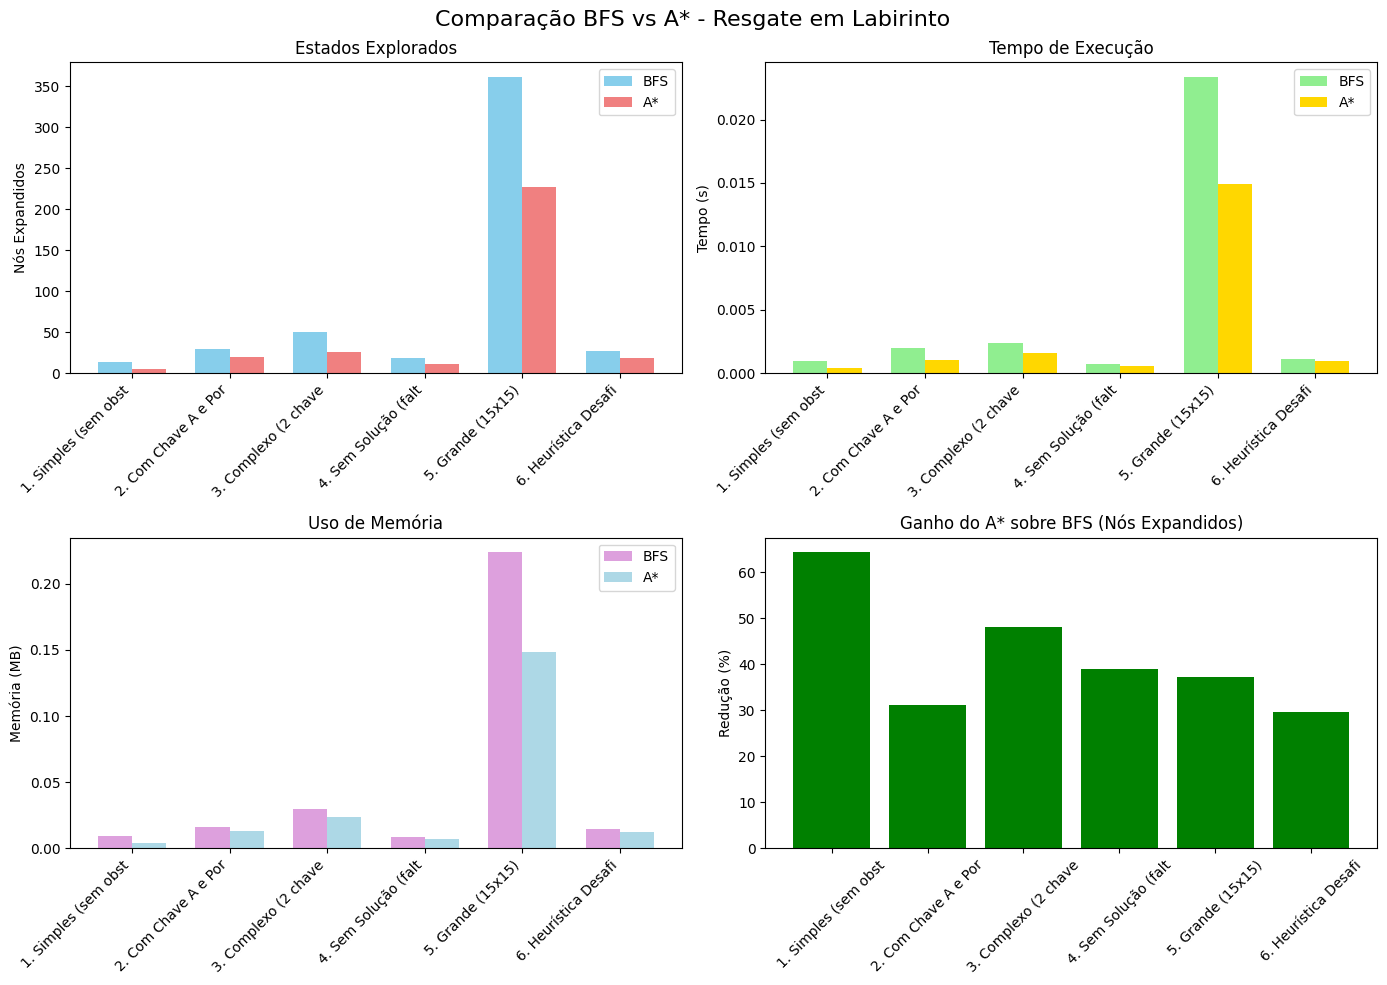


 EXECUÇÃO CONCLUÍDA COM SUCESSO!


In [8]:

# ============================================================================
# EXECUTAR TUDO
# ============================================================================

if __name__ == "__main__":
    executar_no_colab()